# Module 09b: Regression Modelling for CA Professionals

*Himalayan Advisory & Accounting Services Pvt. Ltd. — Kathmandu*

## Part 1: Why Does This Matter to You?

> "Every quarter, the partner asks me how much we'll bill next month. I look at last quarter and guess. We've over-hired in slow months and turned away work in busy ones — all because of bad forecasts."
>
> — Engagement Manager, Kathmandu CA firm

Classification models answered *"will this happen?"* (Yes/No). **Regression models answer *"how much?"*** — a continuous number you can plug straight into a budget, cash-flow forecast, or capacity plan.

For Himalayan Advisory, the partner now wants:

*"For this new engagement — a Construction client in Bagmati, 3-year tenure, NPR 60-day credit terms — what invoice amount should I expect, so I can plan staffing and working capital?"*

That is a **regression problem**: predict a continuous NPR amount, not a Yes/No label.

### The Business Problem

Using the same 900-invoice ledger from Module 08, we will build a model that predicts **`Invoice_Amount` (NPR)** from client history, industry, tenure, and seasonality.

| Question | Model Type | Output |
|----------|-----------|--------|
| Will this client pay late? (Module 09) | Classification | Yes / No |
| **How large will the next invoice be?** | **Regression** | **NPR 4,20,000** |
| What credit days should we offer a new client? | Regression | 30 / 45 / 60 days |

**Why this matters:** an invoice-amount forecast feeds directly into revenue projections, GST/VAT planning, and working-capital sizing.

## Part 2: Fundamentals

### What Linear Regression Actually Does

Linear regression fits a straight line (or hyperplane) through the data by minimising the **sum of squared errors** between predictions and actuals.

```
Invoice_Amount ≈ β₀ + β₁ · Tenure_Years
                    + β₂ · Credit_Days
                    + β₃ · is_high_risk_industry
                    + …
```

Each **β (beta)** is a coefficient the model learns from history. Interpretation is direct: *"each extra year of tenure adds NPR X to the expected invoice."*

### Evaluation Metrics — The CA Interpretation

Classification used Accuracy, Precision, Recall. **Regression uses different metrics** because there is no "right answer" — only "how close".

| Metric | Formula | CA Interpretation |
|--------|---------|------------------|
| **MAE** | mean(\|y − ŷ\|) | Average rupee error per invoice |
| **RMSE** | √mean((y − ŷ)²) | Penalises large errors more (NPR units) |
| **R²** | 1 − SSₛₑₛ/SSₜₒₜ | % of variance explained (0–1 ideally) |
| **MAPE** | mean(\|y − ŷ\| / y) | Average % error |

**For a partner's budget:** MAE in rupees is the most actionable — *"on average, our forecast is off by NPR 80,000 per invoice."*

### Three Models We Will Compare

| Model | What It Does | When To Use |
|-------|-------------|------------|
| **Linear Regression** | Plain OLS — one coefficient per feature | Interpretable baseline |
| **Ridge Regression** | Linear + penalty on large coefficients | Many correlated features |
| **Random Forest Regressor** | Hundreds of decision trees, averaged | Non-linear & interactions |

## Part 3: Hands-on — Build and Evaluate Three Regressors

### Section 1: Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

# Load engineered features from Module 08 — same dataset as Module 09
df = pd.read_csv('nepal_invoice_features.csv')

print(f'Loaded: {df.shape[0]} invoices, {df.shape[1]} columns')
print(f'Target stats — Invoice_Amount (NPR):')
print(df['Invoice_Amount'].describe().round(0).to_string())

Loaded: 900 invoices, 40 columns
Target stats — Invoice_Amount (NPR):
count        900.0
mean      801613.0
std       636376.0
min        36000.0
25%       334750.0
50%       616000.0
75%      1076500.0
max      2974000.0


### Section 2: Prepare Features and Target

The target is `Invoice_Amount`. We must drop **any feature derived from Invoice_Amount** — otherwise the model would "cheat" (data leakage):

- `invoice_credit_ratio` = Invoice_Amount / Credit_Days
- `amount_vs_industry_median`, `daily_obligation`, `is_high_utilisation`, `is_mega_invoice`
- `client_avg_invoice` (computed using this invoice's amount)
- Interaction terms like `risk_x_amount`, `utilisation_x_history`

What remains is **truly predictive**: client characteristics, industry, seasonality, history.

Feature matrix: (900, 23)
Target — Invoice_Amount (NPR):  mean = 801,613   median = 616,000
                                min  = 36,000   max    = 2,974,000


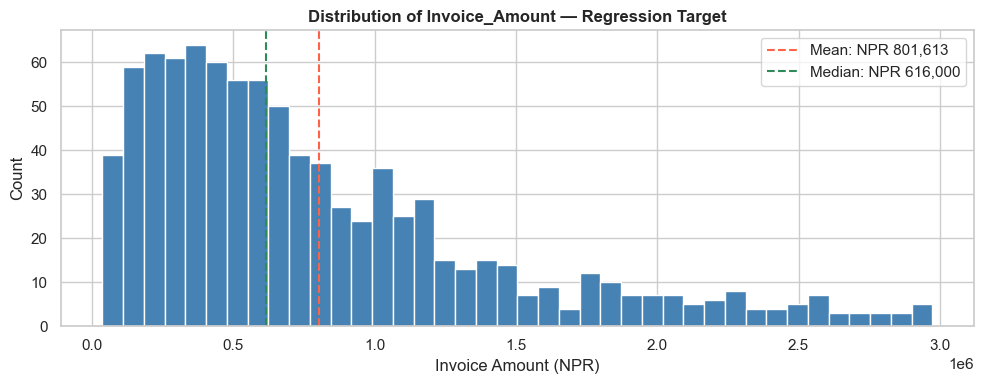

In [2]:
# Features that do NOT leak Invoice_Amount
feature_cols = [
    # Client history (counts and rates — no amount info)
    'prev_late_rate', 'client_total_invoices', 'client_late_rate',
    'client_late_count', 'client_avg_delay',
    # Tenure & credit terms
    'Tenure_Years', 'Credit_Days', 'Prev_Late_Count', 'tenure_band',
    # Binary flags (not derived from Invoice_Amount)
    'is_repeat_offender', 'is_clean_record',
    'is_first_time_client', 'is_long_term_client', 'is_high_risk_industry',
    'is_Q4_due', 'is_dashain_season', 'is_vat_filing_month',
    # Seasonality / dates
    'invoice_quarter', 'due_quarter', 'days_to_fy_end', 'due_on_weekend',
    # Industry encoding (target-encoded on Is_Late — not on amount)
    'industry_target_enc',
    # Interaction (history-only)
    'q4_x_late_history',
]

# Keep only columns that actually exist
feature_cols = [c for c in feature_cols if c in df.columns]

X = df[feature_cols].copy()
y = df['Invoice_Amount'].copy()

print(f'Feature matrix: {X.shape}')
print(f'Target — Invoice_Amount (NPR):  mean = {y.mean():,.0f}   median = {y.median():,.0f}')
print(f'                                min  = {y.min():,.0f}   max    = {y.max():,.0f}')

# Quick visual of the target distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(y, bins=40, color='steelblue', edgecolor='white')
ax.axvline(y.mean(), color='tomato', linestyle='--', label=f'Mean: NPR {y.mean():,.0f}')
ax.axvline(y.median(), color='seagreen', linestyle='--', label=f'Median: NPR {y.median():,.0f}')
ax.set_xlabel('Invoice Amount (NPR)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Invoice_Amount — Regression Target', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

In [3]:
# Train / Test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

# Fill any NaNs with column median (some history features can be NaN for first-time clients)
X_train = X_train.fillna(X_train.median(numeric_only=True))
X_test  = X_test.fillna(X_train.median(numeric_only=True))

print(f'Training set: {X_train.shape[0]} invoices   mean NPR {y_train.mean():,.0f}')
print(f'Test set:     {X_test.shape[0]} invoices   mean NPR {y_test.mean():,.0f}')

Training set: 720 invoices   mean NPR 797,492
Test set:     180 invoices   mean NPR 818,100


### Section 3: Model 1 — Linear Regression (OLS Baseline)

The classical workhorse. Easy to interpret — each coefficient says how many NPR a one-unit change in that feature adds (or removes) from the predicted invoice amount.

In [4]:
# Scale features (good practice for linear models, especially Ridge later)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# Fit Linear Regression
lr = LinearRegression()
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)

# Metrics
mae_lr  = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr   = r2_score(y_test, y_pred_lr)
mape_lr = np.mean(np.abs((y_test - y_pred_lr) / y_test)) * 100

print('=== Linear Regression — Test Set Results ===')
print(f'  MAE   : NPR {mae_lr:,.0f}     (typical error per invoice)')
print(f'  RMSE  : NPR {rmse_lr:,.0f}     (penalises large misses)')
print(f'  R²    : {r2_lr:.4f}              (1.0 = perfect, 0 = no better than mean)')
print(f'  MAPE  : {mape_lr:.1f}%             (avg % error vs actual)')

=== Linear Regression — Test Set Results ===
  MAE   : NPR 484,264     (typical error per invoice)
  RMSE  : NPR 641,403     (penalises large misses)
  R²    : 0.0331              (1.0 = perfect, 0 = no better than mean)
  MAPE  : 127.1%             (avg % error vs actual)


### Section 4: Model 2 — Ridge Regression

Ridge is Linear Regression **with a penalty on large coefficients**. When features are correlated (e.g. `client_total_invoices`, `client_late_count`, `client_avg_delay` all move together), plain OLS can swing wildly. Ridge keeps coefficients stable.

In [5]:
ridge = Ridge(alpha=10.0, random_state=42)
ridge.fit(X_train_sc, y_train)
y_pred_ridge = ridge.predict(X_test_sc)

mae_ridge  = mean_absolute_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)
mape_ridge = np.mean(np.abs((y_test - y_pred_ridge) / y_test)) * 100

print('=== Ridge Regression (alpha=10) — Test Set Results ===')
print(f'  MAE   : NPR {mae_ridge:,.0f}')
print(f'  RMSE  : NPR {rmse_ridge:,.0f}')
print(f'  R²    : {r2_ridge:.4f}')
print(f'  MAPE  : {mape_ridge:.1f}%')

=== Ridge Regression (alpha=10) — Test Set Results ===
  MAE   : NPR 484,213
  RMSE  : NPR 639,978
  R²    : 0.0374
  MAPE  : 127.8%


### Section 5: Model 3 — Random Forest Regressor

Random Forest builds many decision trees and averages their numeric predictions. It captures **non-linear effects** (e.g. invoice amount might rise with tenure up to 5 years then plateau) and **interactions** (Dashain + Construction = unusually large invoices) without needing them hand-engineered.

In [6]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)            # Trees don't need scaling
y_pred_rf = rf.predict(X_test)

mae_rf  = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf   = r2_score(y_test, y_pred_rf)
mape_rf = np.mean(np.abs((y_test - y_pred_rf) / y_test)) * 100

print('=== Random Forest Regressor — Test Set Results ===')
print(f'  MAE   : NPR {mae_rf:,.0f}')
print(f'  RMSE  : NPR {rmse_rf:,.0f}')
print(f'  R²    : {r2_rf:.4f}')
print(f'  MAPE  : {mape_rf:.1f}%')

=== Random Forest Regressor — Test Set Results ===
  MAE   : NPR 358,855
  RMSE  : NPR 475,277
  R²    : 0.4691
  MAPE  : 79.0%


### Section 6: Model Comparison — Side-by-Side

The partner doesn't care about algorithms — only which forecast is closer to reality.

In [7]:
results = pd.DataFrame({
    'Model':  ['Linear Regression', 'Ridge Regression', 'Random Forest'],
    'MAE (NPR)':  [mae_lr, mae_ridge, mae_rf],
    'RMSE (NPR)': [rmse_lr, rmse_ridge, rmse_rf],
    'R²':         [r2_lr, r2_ridge, r2_rf],
    'MAPE %':     [mape_lr, mape_ridge, mape_rf],
}).round(2)
print('=== Model Comparison — Invoice Amount Forecasting ===')
print(results.to_string(index=False))

best_idx = results['MAE (NPR)'].idxmin()
print(f'\nBest by MAE: {results.loc[best_idx, "Model"]} '
      f'(off by NPR {results.loc[best_idx, "MAE (NPR)"]:,.0f} per invoice on average)')

=== Model Comparison — Invoice Amount Forecasting ===
            Model  MAE (NPR)  RMSE (NPR)   R²  MAPE %
Linear Regression  484264.40   641402.98 0.03  127.14
 Ridge Regression  484213.08   639977.90 0.04  127.77
    Random Forest  358855.20   475276.76 0.47   79.05

Best by MAE: Random Forest (off by NPR 358,855 per invoice on average)


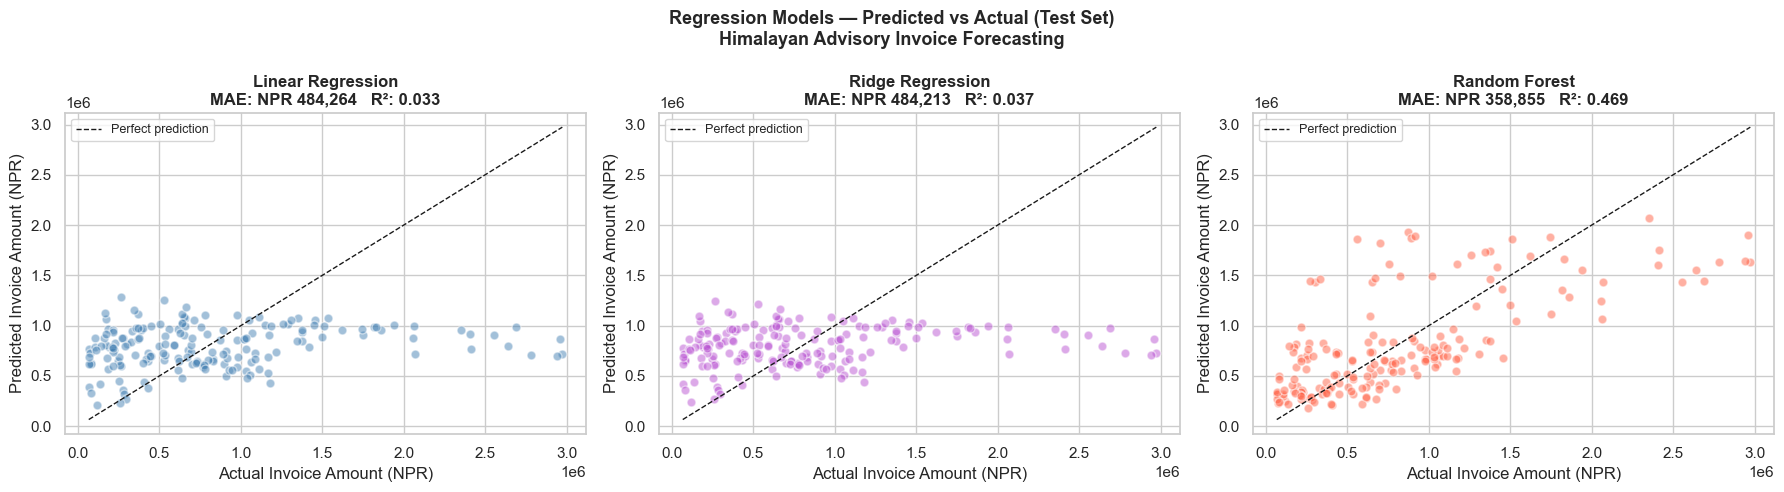

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regression Models — Predicted vs Actual (Test Set)\nHimalayan Advisory Invoice Forecasting',
             fontsize=13, fontweight='bold')

predictions = [(y_pred_lr, 'Linear Regression', 'steelblue', mae_lr, r2_lr),
               (y_pred_ridge, 'Ridge Regression', 'mediumorchid', mae_ridge, r2_ridge),
               (y_pred_rf, 'Random Forest', 'tomato', mae_rf, r2_rf)]

lo, hi = y_test.min(), y_test.max()
for ax, (y_pred, name, color, mae, r2) in zip(axes, predictions):
    ax.scatter(y_test, y_pred, alpha=0.5, color=color, edgecolor='white', s=40)
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='Perfect prediction')
    ax.set_xlabel('Actual Invoice Amount (NPR)')
    ax.set_ylabel('Predicted Invoice Amount (NPR)')
    ax.set_title(f'{name}\nMAE: NPR {mae:,.0f}   R²: {r2:.3f}', fontweight='bold')
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

### Section 7: Residual Analysis — Where Does the Model Miss?

A residual is `actual − predicted`. A good model has residuals scattered randomly around zero — no pattern. **A pattern in residuals means we're missing a feature.**

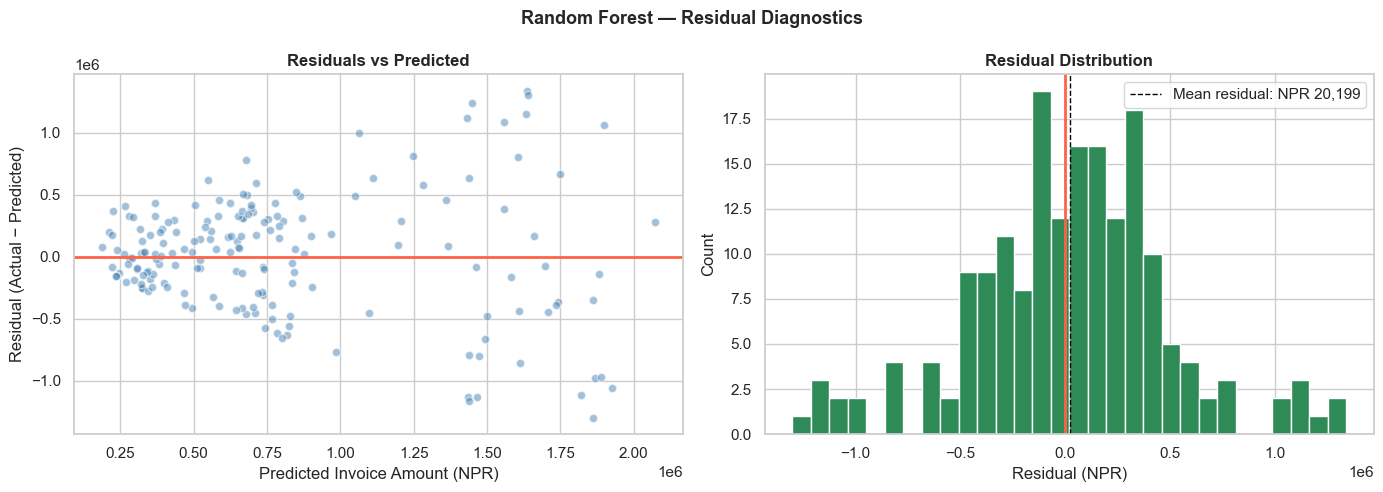

Residual stats (NPR):
  Mean:         20,199   (should be near 0 — no systematic bias)
  Std:         476,172   (typical scatter)
  Worst over-forecast:    -1,300,757
  Worst under-forecast:    1,339,182


In [9]:
# Use the best model (Random Forest by default — will work for any of the three)
residuals = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Random Forest — Residual Diagnostics', fontweight='bold', fontsize=13)

# Residuals vs predicted
axes[0].scatter(y_pred_rf, residuals, alpha=0.5, color='steelblue', edgecolor='white')
axes[0].axhline(0, color='tomato', lw=2)
axes[0].set_xlabel('Predicted Invoice Amount (NPR)')
axes[0].set_ylabel('Residual (Actual − Predicted)')
axes[0].set_title('Residuals vs Predicted', fontweight='bold')

# Residual distribution
axes[1].hist(residuals, bins=30, color='seagreen', edgecolor='white')
axes[1].axvline(0, color='tomato', lw=2)
axes[1].axvline(residuals.mean(), color='black', lw=1, linestyle='--',
                 label=f'Mean residual: NPR {residuals.mean():,.0f}')
axes[1].set_xlabel('Residual (NPR)')
axes[1].set_ylabel('Count')
axes[1].set_title('Residual Distribution', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Residual stats (NPR):')
print(f'  Mean:   {residuals.mean():>12,.0f}   (should be near 0 — no systematic bias)')
print(f'  Std:    {residuals.std():>12,.0f}   (typical scatter)')
print(f'  Worst over-forecast:  {residuals.min():>12,.0f}')
print(f'  Worst under-forecast: {residuals.max():>12,.0f}')

### Section 8: What Drives Invoice Size?

Random Forest's feature importance answers the partner's real question: *"What client characteristics make an invoice big?"*

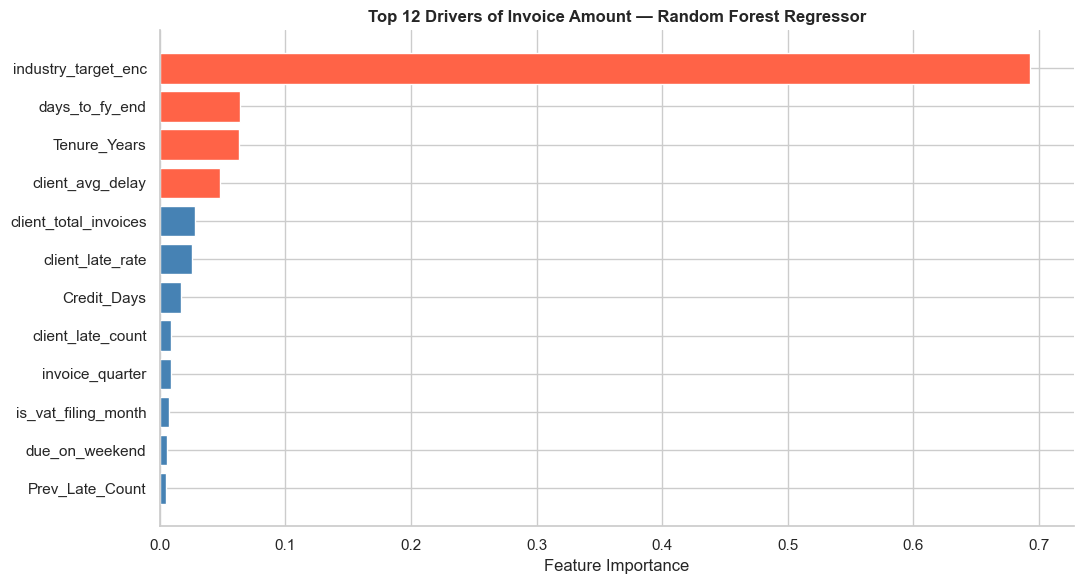

Top 5 drivers of invoice amount:
  industry_target_enc          0.6934  ███████████████████████████████████████████████████████
  days_to_fy_end               0.0640  █████
  Tenure_Years                 0.0630  █████
  client_avg_delay             0.0483  ███
  client_total_invoices        0.0279  ██


In [10]:
importance_df = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['tomato' if i < 4 else 'steelblue' for i in range(len(importance_df))]
ax.barh(importance_df['Feature'][::-1], importance_df['Importance'][::-1],
        color=colors[::-1], edgecolor='white')
ax.set_xlabel('Feature Importance')
ax.set_title('Top 12 Drivers of Invoice Amount — Random Forest Regressor',
             fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print('Top 5 drivers of invoice amount:')
for _, row in importance_df.head(5).iterrows():
    bar = '█' * int(row['Importance'] * 80)
    print(f'  {row["Feature"]:<28} {row["Importance"]:.4f}  {bar}')

### Section 9: Putting It To Work — Forecast a New Engagement

The partner walks in: *"I'm pitching a Construction client, 3 years tenure, 60-day credit terms, never been late, invoice will be raised in Q4 during Dashain. What should I quote?"*

In [11]:
# Build a single-row DataFrame mirroring our training features
new_engagement = pd.DataFrame([{
    'prev_late_rate':         0.0,    # never been late
    'client_total_invoices':  4,      # 4 prior invoices on file
    'client_late_rate':       0.0,
    'client_late_count':      0,
    'client_avg_delay':       0.0,
    'Tenure_Years':           3.0,
    'Credit_Days':            60,
    'Prev_Late_Count':        0,
    'tenure_band':            2,      # mid-tenure
    'is_repeat_offender':     0,
    'is_clean_record':        1,
    'is_first_time_client':   0,
    'is_long_term_client':    0,
    'is_high_risk_industry':  1,      # Construction = high-risk
    'is_Q4_due':              1,
    'is_dashain_season':      1,
    'is_vat_filing_month':    0,
    'invoice_quarter':        4,
    'due_quarter':            4,
    'days_to_fy_end':         45,
    'due_on_weekend':         0,
    'industry_target_enc':    df.loc[df['Industry']=='Construction', 'industry_target_enc'].mean(),
    'q4_x_late_history':      0.0,
}])

# Align column order to training
new_engagement = new_engagement[feature_cols]

# Predict with all three models
pred_lr_new    = lr.predict(scaler.transform(new_engagement))[0]
pred_ridge_new = ridge.predict(scaler.transform(new_engagement))[0]
pred_rf_new    = rf.predict(new_engagement)[0]

print('=== Forecast for New Construction Engagement ===')
print(f'  Linear Regression : NPR {pred_lr_new:>10,.0f}')
print(f'  Ridge Regression  : NPR {pred_ridge_new:>10,.0f}')
print(f'  Random Forest     : NPR {pred_rf_new:>10,.0f}')
print(f'\n  Recommendation to partner: quote ~NPR {pred_rf_new:,.0f} '
      f'(± NPR {mae_rf:,.0f} typical error)')

=== Forecast for New Construction Engagement ===
  Linear Regression : NPR  1,001,820
  Ridge Regression  : NPR  1,001,087
  Random Forest     : NPR  1,428,576

  Recommendation to partner: quote ~NPR 1,428,576 (± NPR 358,855 typical error)


## Part 4: Practice Exercises

---

#### Exercise 1 — Tune Ridge's Penalty

`Ridge(alpha=...)` controls how aggressively the model shrinks coefficients. Larger alpha = simpler model, less overfitting.

1. Try `alpha` values: `[0.1, 1, 10, 100, 1000]`
2. For each, fit on training, predict on test, record `R²` and `MAE`
3. Plot R² vs alpha (log scale on x-axis). Where does R² peak?

---

#### Exercise 2 — Linear Regression Coefficients

Build a coefficient table for the **Linear Regression** model:

1. Pair each feature name with its coefficient (`lr.coef_`)
2. Sort by absolute value descending
3. Plot a horizontal bar chart: positive coefficients in green (push invoice up), negative in red (push down)
4. Write 2 sentences interpreting the top positive and top negative coefficient for a partner

---

#### Exercise 3 — Industry-Level Invoice Forecast

Use the Random Forest to predict invoice amounts for **all** rows in `df`. Then:

1. Compute predicted average invoice per `Industry`
2. Compare to **actual** average invoice per `Industry`
3. Which industry does the model **over-forecast**? Which does it **under-forecast**?

---

*Solutions in cells below.*

---

 alpha     R2         MAE
   0.1 0.0332 484260.2193
   1.0 0.0337 484220.6661
  10.0 0.0374 484213.0795
 100.0 0.0457 485636.2338
1000.0 0.0295 487608.3212


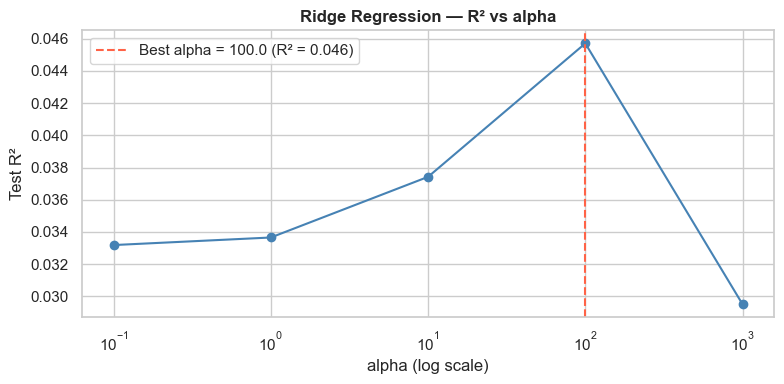

In [12]:
# SOLUTION — Exercise 1: Tune Ridge's alpha
alphas = [0.1, 1, 10, 100, 1000]
tuning = []
for a in alphas:
    r = Ridge(alpha=a, random_state=42).fit(X_train_sc, y_train)
    p = r.predict(X_test_sc)
    tuning.append({'alpha': a,
                    'R2':  r2_score(y_test, p),
                    'MAE': mean_absolute_error(y_test, p)})
tuning_df = pd.DataFrame(tuning)
print(tuning_df.round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(tuning_df['alpha'], tuning_df['R2'], marker='o', color='steelblue')
ax.set_xscale('log')
ax.set_xlabel('alpha (log scale)')
ax.set_ylabel('Test R²')
ax.set_title('Ridge Regression — R² vs alpha', fontweight='bold')
best = tuning_df.loc[tuning_df['R2'].idxmax()]
ax.axvline(best['alpha'], color='tomato', linestyle='--',
            label=f'Best alpha = {best["alpha"]} (R² = {best["R2"]:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

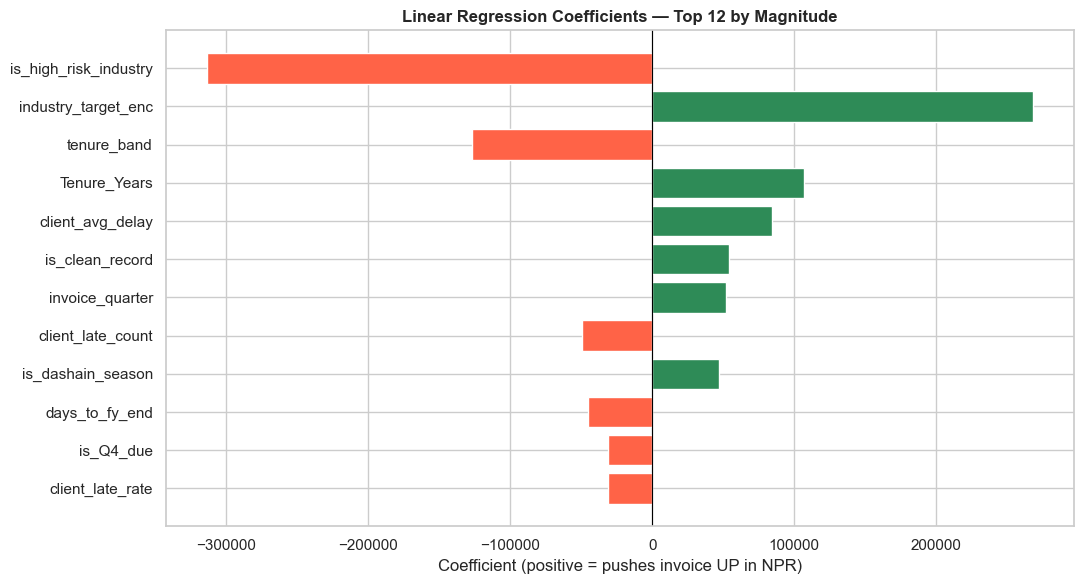

Top upward driver  : industry_target_enc          (+267,978 NPR per std)
Top downward driver: is_high_risk_industry        (-313,434 NPR per std)


In [13]:
# SOLUTION — Exercise 2: Linear Regression coefficients
coef_df = pd.DataFrame({
    'Feature': feature_cols,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', key=abs, ascending=False).head(12)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['seagreen' if c > 0 else 'tomato' for c in coef_df['Coefficient'][::-1]]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1],
        color=colors, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient (positive = pushes invoice UP in NPR)')
ax.set_title('Linear Regression Coefficients — Top 12 by Magnitude',
             fontweight='bold')
plt.tight_layout()
plt.show()

top_pos = coef_df[coef_df['Coefficient'] > 0].iloc[0]
top_neg = coef_df[coef_df['Coefficient'] < 0].iloc[0]
print(f'Top upward driver  : {top_pos["Feature"]:<28} (+{top_pos["Coefficient"]:,.0f} NPR per std)')
print(f'Top downward driver: {top_neg["Feature"]:<28} ({top_neg["Coefficient"]:,.0f} NPR per std)')

In [14]:
# SOLUTION — Exercise 3: Industry-level forecast vs actual
X_all = df[feature_cols].fillna(df[feature_cols].median(numeric_only=True))
df_pred = df.copy()
df_pred['Predicted_Invoice'] = rf.predict(X_all)

industry_view = df_pred.groupby('Industry').agg(
    Invoices=('Invoice_ID', 'count'),
    Actual_Avg=('Invoice_Amount', 'mean'),
    Predicted_Avg=('Predicted_Invoice', 'mean'),
).round(0)
industry_view['Gap_NPR'] = (industry_view['Predicted_Avg'] - industry_view['Actual_Avg']).round(0)
industry_view['Gap_%']  = (industry_view['Gap_NPR'] / industry_view['Actual_Avg'] * 100).round(1)
industry_view = industry_view.sort_values('Gap_NPR', ascending=False)

print('=== Industry-Level Forecast vs Actual ===')
print(industry_view.to_string())
print()
print(f'Most over-forecast : {industry_view.index[0]} '
      f'(model predicts NPR {industry_view["Gap_NPR"].iloc[0]:,.0f} too high)')
print(f'Most under-forecast: {industry_view.index[-1]} '
      f'(model predicts NPR {abs(industry_view["Gap_NPR"].iloc[-1]):,.0f} too low)')

=== Industry-Level Forecast vs Actual ===
                   Invoices  Actual_Avg  Predicted_Avg  Gap_NPR  Gap_%
Industry                                                              
Construction            107   1355579.0      1367999.0  12420.0    0.9
Tourism & Hotels        108    314574.0       322617.0   8043.0    2.6
Agriculture              47    236809.0       244210.0   7401.0    3.1
Banking & Finance        75    486587.0       488892.0   2305.0    0.5
Trading & Import        213    682465.0       679801.0  -2664.0   -0.4
Services & IT            86    390093.0       377747.0 -12346.0   -3.2
Hydropower              120   1702525.0      1685861.0 -16664.0   -1.0
Manufacturing           144    774938.0       755498.0 -19440.0   -2.5

Most over-forecast : Construction (model predicts NPR 12,420 too high)
Most under-forecast: Manufacturing (model predicts NPR 19,440 too low)


## Wrap-up

You now have **both halves** of supervised learning for CA work:

| Module | Predicts | Output | Useful For |
|--------|----------|--------|-----------|
| **09 — Classification** | Late or Not | Yes/No + probability | Credit risk, collections priority |
| **09b — Regression (this one)** | Invoice amount | NPR value | Revenue forecasting, capacity planning |

**Same data. Same workflow. Different target — different metric.** That is the punchline of supervised learning.